<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Tarea_1_2_Optimizaci%C3%B3n_escalar_con_SymPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problemas de optimización escalar
Resuelva los siguientes problemas usando la librería `SymPy`. Use celdas en `Markdown` para explicar su procedimiento, así como los resultados obtenidos.

1. El perímetro de un triángulo isósceles es de $10 cm$. ¿Cuánto deben medir sus lados para que el volumen del cuerpo generado por la rotación del triángulo en torno a su base sea el mayor posible? (Volumen de un cono $= \frac{1}{3}\pi r^2 h$, donde $r$ es el radio de la base y $h$ la altura del cono).

In [1]:
import sympy as sp
sp.nsimplify  # evitar warning si se usa en algunos entornos

# Símbolos
b = sp.symbols('b', real=True)

# Definiciones
s = (10 - b)/2                   # lados iguales
h2 = s**2 - (b/2)**2             # h^2
V = sp.simplify(sp.pi * b * h2 / 3)  # Volumen simbólico

# Derivadas
dV = sp.diff(V, b)
d2V = sp.diff(dV, b)

# Resolver crítico en (0,10)
crit_all = sp.solve(sp.Eq(dV, 0), b)
crit_valid = [c for c in crit_all if c.is_real and 0 < float(c) < 10]

# Evaluaciones
extremos = [0, 10]
puntos_eval = crit_valid + extremos
evaluaciones = [(c, sp.simplify(V.subs(b, c))) for c in puntos_eval]

# Valores numéricos óptimos
b_opt = crit_valid[0]
s_opt = sp.simplify((10 - b_opt)/2)
h_opt = sp.sqrt(sp.simplify(h2.subs(b, b_opt)))
V_opt = sp.simplify(V.subs(b, b_opt))

# Comprobación de segunda derivada en el crítico
d2V_at_opt = sp.simplify(d2V.subs(b, b_opt))

# Resultados impresos
print("Expresión simbólica de V(b):", V)
print("\nDerivada dV/db:", dV)
print("Segunda derivada d2V/db2:", d2V)
print("\nTodos los puntos críticos simbólicos:", crit_all)
print("Puntos críticos válidos en (0,10):", crit_valid)
print("\nEvaluación de V en críticos y extremos:")
for c, val in evaluaciones:
    print(" b =", c, " -> V =", val)

print("\nResultado óptimo (simbólico y numérico):")
print(" b_opt =", b_opt, " = ", float(b_opt), " cm")
print(" s (lado igual) =", s_opt, " = ", float(s_opt), " cm")
print(" h (altura) =", sp.simplify(h_opt), " = ", float(h_opt), " cm")
print(" V_max =", V_opt, " = ", float(V_opt), " (unidades de volumen, incluye π si está simbólico)")

print("\nSegunda derivada en b_opt:", d2V_at_opt, " (si es <0 es máximo)")


Expresión simbólica de V(b): 5*pi*b*(5 - b)/3

Derivada dV/db: -5*pi*b/3 + 5*pi*(5 - b)/3
Segunda derivada d2V/db2: -10*pi/3

Todos los puntos críticos simbólicos: [5/2]
Puntos críticos válidos en (0,10): [5/2]

Evaluación de V en críticos y extremos:
 b = 5/2  -> V = 125*pi/12
 b = 0  -> V = 0
 b = 10  -> V = -250*pi/3

Resultado óptimo (simbólico y numérico):
 b_opt = 5/2  =  2.5  cm
 s (lado igual) = 15/4  =  3.75  cm
 h (altura) = 5*sqrt(2)/2  =  3.5355339059327378  cm
 V_max = 125*pi/12  =  32.72492347489368  (unidades de volumen, incluye π si está simbólico)

Segunda derivada en b_opt: -10*pi/3  (si es <0 es máximo)


2. Disponemos de una barra de aluminio de 6 metros para construir una portería de fútbol. Si queremos que el área de la portería sea máxima, ¿cuánto deben medir los postes y el travesaño?

A(h) = -2*h**2 + 6*h
A'(h) = 6 - 4*h
A''(h) = -4

Punto crítico válido: 3/2 m
Travesaño w = 3 m
Área máxima A = 9/2 m^2
Segunda derivada en h_opt: -4 (<0 ⇒ máximo)


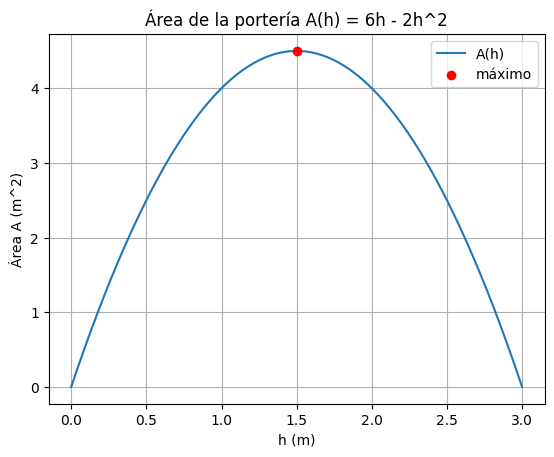

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Símbolos
h = sp.symbols('h', real=True)

# Área como función de h
A = 6*h - 2*h**2  # equival. a h*(6-2*h)

# Derivadas
dA = sp.diff(A, h)
d2A = sp.diff(dA, h)

# Punto crítico
crit = sp.solve(sp.Eq(dA, 0), h)
crit_valid = [c for c in crit if c.is_real and 0 < float(c) < 3]  # h>0 y w=6-2h>0 => h<3

# Resultado óptimo
h_opt = crit_valid[0]
w_opt = 6 - 2*h_opt
A_opt = sp.simplify(A.subs(h, h_opt))
d2A_at_opt = d2A.subs(h, h_opt)

# Imprimir resultados
print("A(h) =", A)
print("A'(h) =", dA)
print("A''(h) =", d2A)
print("\nPunto crítico válido:", h_opt, "m")
print("Travesaño w =", sp.simplify(w_opt), "m")
print("Área máxima A =", sp.simplify(A_opt), "m^2")
print("Segunda derivada en h_opt:", d2A_at_opt, "(<0 ⇒ máximo)")

# Gráfica de A(h) en el intervalo válido (0,3)
h_vals = np.linspace(0, 3, 400)
A_func = sp.lambdify(h, A, 'numpy')
plt.plot(h_vals, A_func(h_vals), label="A(h)")
plt.scatter([float(h_opt)], [float(A_opt)], color='red', zorder=5, label='máximo')
plt.xlabel("h (m)")
plt.ylabel("Área A (m^2)")
plt.title("Área de la portería A(h) = 6h - 2h^2")
plt.legend()
plt.grid(True)
plt.show()


Le pregunte a ChatGPT, esta tarea se me hizo muy dificil